In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from collections import defaultdict

In [16]:
# data = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/normal/direct/1_2505.csv",header= None)
# data2 = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/rating/OurMethod/1_138494.csv",header= None)
original = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/fire/trainGraph.csv",header = None)
# excluded = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/normal/testGraph.csv",header=None,sep=",")

In [17]:
(sum(original[0].value_counts().values)+sum(original[1].value_counts().values))/(sum(original[0].unique())+sum(original[1].unique()))

np.float64(0.0009102998482000231)

In [26]:
def compute_degrees(edges):
    left_deg = defaultdict(int)
    right_deg = defaultdict(int)

    for l, r in edges:
        left_deg[l] += 1
        right_deg[r] += 1

    return left_deg, right_deg

def normalize_probs_log(r, left_deg, right_deg, eps=1e-9):
    """
    probs: lista de [left, right, p]
    """
    new_probs = []

    dl = left_deg[r[0]]
    dr = right_deg[r[1]]

    # evitar log(0)
    c_left = np.log1p(dl)
    c_right = np.log1p(dr)

    # ajuste
    p_new = r[2] * (c_left / (c_right + eps))


    return p_new

In [27]:
left_deg, right_deg = compute_degrees(list(zip(data[0].values, data[1].values)))
data[2] = data.apply(lambda r: normalize_probs_log(r, left_deg, right_deg), axis=1)


In [28]:
data

,0,1,2
0,2505,139590,1.545961
1,2505,139620,0.515322
2,2505,140006,1.545961
3,2505,140080,1.030640
4,2505,140214,0.515322
...,...,...,...
506869,2505,143175,0.077298
506870,2505,143178,0.077298
506871,2505,145293,0.077298
506872,2505,147461,0.000000


In [29]:
# values = []
# for i,j in data.groupby(1):
    
#     values.append([j[0].values[0],j[1].values[0],j[2].values])

values2 = []
for i,j in data.groupby(1):
    
    values2.append([j[0].values[0],j[1].values[0],j[2].values])


In [3]:
import subprocess

nn = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/exp/movies/ratingtrainGraph.csv",header=None)
# nn.drop(nn[nn[1] == 2051].head(50).index,inplace=True)
current_path = "/home/edu/Area_de_Trabalho/Projs/links/"
def calculate_metric(train_graph):

        train_graph["weight"] = 1
        train_graph.to_csv(f"{current_path}/data/kpisti-L3-a163e9f/graph.txt",header=None,sep=" ",index=False)
        subprocess.run(f"/home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/teste.out /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/graph.txt", shell=True)
        subprocess.run(f"mv /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/L3_predictions_graph.txt.dat /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/L3_predictions_graph.txt", shell=True)
        result = pd.read_csv(f"{current_path}/data/kpisti-L3-a163e9f/L3_predictions_graph.txt",sep="\t",header=None)
        result.columns = ["left_nodes","right_nodes","pred"]
        return result

aux = calculate_metric(nn)

In [5]:
aux.head(10)

,left_nodes,right_nodes,pred
0,139703,18611,179.705
1,138950,18611,174.875
2,139020,18611,172.586
3,139101,18611,162.915
4,138873,18611,144.819
5,139141,18611,144.301
6,139529,18611,143.881
7,141351,84476,141.676
8,141121,18611,140.477
9,139784,18611,139.804


In [4]:
# df = pd.DataFrame(values)
df2 = pd.DataFrame(values2)

In [30]:
# df = pd.DataFrame(values)
df2 = pd.DataFrame(values2)
pares_data = set(zip(data[0], data[1]))
pares_original = set(zip(original[0], original[1]))

pares_validos = pares_data & pares_original   # interseção
df2["label"] = (
    list(zip(df2[0], df2[1]))
)

df2[4] = (
    list(zip(df2[0], df2[1]))
)

# df["label"] = (
#     list(zip(df[0], df[1]))
# )

# df["label"] = df["label"].copy().isin(pares_validos).astype(int)

df2["label"] = df2["label"].copy().isin(pares_validos).astype(int)
# df2 = df2[df2[2].apply(lambda x: set(x) != {0})]

# aux2 = aux[aux["right_nodes"] == 150]
# pares_l3 = set(zip(aux2["right_nodes"].head(50),aux2["left_nodes"].head(50)))
df2["orig"] = df2[1].isin(excluded[excluded[0]==18611][1]).astype(int)
# df2[4] = df2[1].isin([138857,138870,138928,138939,138950,138993,139020,139044,139081,139085,139086,139087,139143,139166,139213,139217,139226,139259,139297,139323])




In [31]:
# teste = (pd.DataFrame([i for i in df[2].values]))
teste2 = (pd.DataFrame([i for i in df2[2].values]))
# teste2 = teste2.loc[:, (teste2 != 0).any(axis=0)]



I0000 00:00:1775950232.760144  110859 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775950240.753080  110859 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


<Figure size 2500x2500 with 0 Axes>

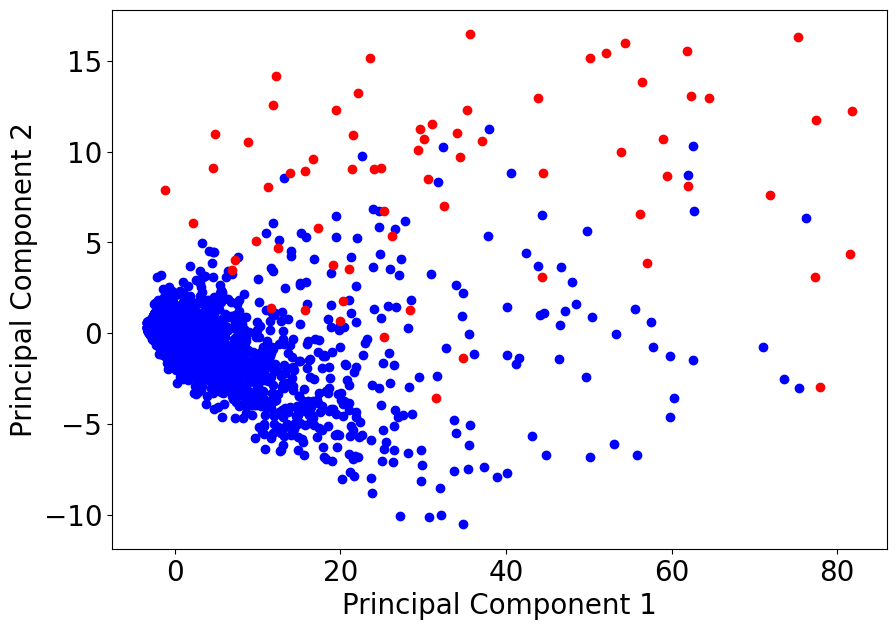

In [33]:
import plotly.express as px7
import umap
from sklearn.manifold import TSNE

fig = plt.figure(figsize=(25,25))
# teste2 = teste2.T
# teste2 = teste2.rolling(window=25,axis=1, center=True,min_periods=1).mean()

for col in teste2.columns:
    media = teste2[col].mean()
    teste2.loc[teste2[col].isin([0, 1]), col] = media


scaler = StandardScaler()
X_scaled = scaler.fit_transform(teste2.dropna().reset_index(drop=True))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# tsne = TSNE(n_components=2, random_state=0, perplexity=15)
# X_embedded = tsne.fit_transform(np.array(teste2))


# reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, n_components=2, random_state=42)
# values = reducer.fit_transform(teste2)


scaled_df = pd.concat([pd.DataFrame(X_pca),df2["label"],df2["orig"]],axis=1)


red = scaled_df[scaled_df["label"] == 1]
blue = scaled_df[scaled_df["label"] == 0]
# blue = blue.sample(200)
green = scaled_df[scaled_df["orig"] == 1]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot()


ax.scatter(blue[[0]], blue[[1]],c="blue")
ax.scatter(red[[0]], red[[1]],c="red")
ax.scatter(green[[0]],green[[1]],c="Yellow",marker= "X",s=100)

# ax.set_ylim(-5,15)
# ax.set_xlim(15,35)


plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel('Principal Component 1', fontsize=20)
plt.ylabel('Principal Component 2', fontsize=20)


# fig = px.scatter(x=scaled_df[0],y=scaled_df[1], color=scaled_df["label"],
#                  title="Scatter Plot with Iteratively Added Trace")

# fig.show()
plt.savefig("pca1.png", bbox_inches='tight', pad_inches=0)



In [65]:
blue

,0,1,label
11,-20.181350,-11.881589,0
13,0.400661,-18.768541,0
14,-10.510366,-17.774830,0
16,30.585585,-25.688110,0
17,8.998508,-23.780163,0
...,...,...,...
7485,-23.173257,-15.171831,0
7486,-22.303543,-15.540356,0
7487,-22.666720,-16.978510,0
7488,-22.676713,-17.237983,0


In [13]:
for i in red[[0,1]].values:
    print(f"({i[0]},{i[1]})")

(81.6260474077269,-1.3961722688752278)
(7.891409330429416,15.050644370275656)
(2.620229531633292,13.538733775442005)
(48.83006313739402,2.278181539464774)
(66.77109032583492,2.5063231617359847)
(62.535347462004104,3.2284498462148354)
(30.67567535584726,8.2072101717158)
(35.46626119768435,10.833529397214107)
(11.347002745664948,10.451951039265744)
(1.6645432276108278,13.534498758619886)
(53.98320035926401,4.611697336079352)
(41.79754602946822,7.434573482976734)
(20.884073290809937,11.113337551783722)
(21.736664021456356,10.716285746242729)
(23.53897897610925,7.089712552459892)
(44.1674111044792,7.11307265618558)
(44.90655001467894,6.492037886798689)
(16.29278003479866,11.154330586317565)
(33.662759117697526,10.482699348609515)
(27.92762962998758,7.437422623828985)
(29.420714870954043,1.4194487083173675)
(67.17572254023413,-0.2881230191485216)
(77.98805428375528,-2.9569779571065222)
(27.081699454690153,8.23282389589145)
(9.237867424422378,11.660640240916187)
(82.82447294792257,-4.6093326

In [ ]:
from sklearn.metrics.pairwise import cosine_distances
distancias = cosine_distances(teste2.values)
matriz_dist = pd.DataFrame(distancias, index=teste2.index, columns=teste2.index)

In [ ]:
teste2.iloc[7635,:].value_counts()

In [ ]:
df2[df2.index.isin(matriz_dist[22].sort_values(ascending=False).index.values[0:5])]

In [ ]:
matriz_dist[2000].sort_values(ascending=False)

In [106]:
df.iloc[0,:].values[2]

array([0.588235, 0.5625  , 0.714286, 0.666667, 0.375   , 0.75    ,
       0.714286, 0.565217, 0.8     , 0.651163, 0.666667, 0.705882,
       0.8     , 0.585366, 0.685714, 0.75    , 0.666667, 0.333333,
       0.727273, 0.769231, 0.608108, 0.5     , 0.666667, 0.666667,
       0.666667, 0.      , 0.774194, 0.333333, 0.709677, 0.5     ,
       0.5     , 0.76087 , 0.333333, 0.789474, 0.5     , 0.551724,
       0.619048, 0.      , 0.      , 0.636364, 0.683333, 0.657143,
       0.      , 0.689655, 0.583333, 0.777778, 0.714286, 0.      ,
       0.666667, 0.666667, 0.738095, 0.8     , 0.6875  , 0.571429,
       0.71875 , 0.5     , 0.4     , 0.363636, 0.571429, 0.540984,
       0.557143, 0.690476, 0.785714, 0.65    , 0.666667, 0.904762,
       0.645161, 0.518519, 0.644068, 0.545455, 0.5     , 0.675   ,
       0.634615, 0.631579, 0.533333, 0.55    , 0.571429, 0.702128,
       0.      , 0.833333, 0.586207, 0.333333, 0.565217, 0.857143,
       0.      , 0.545455, 0.666667, 0.6     , 0.636364, 0.636

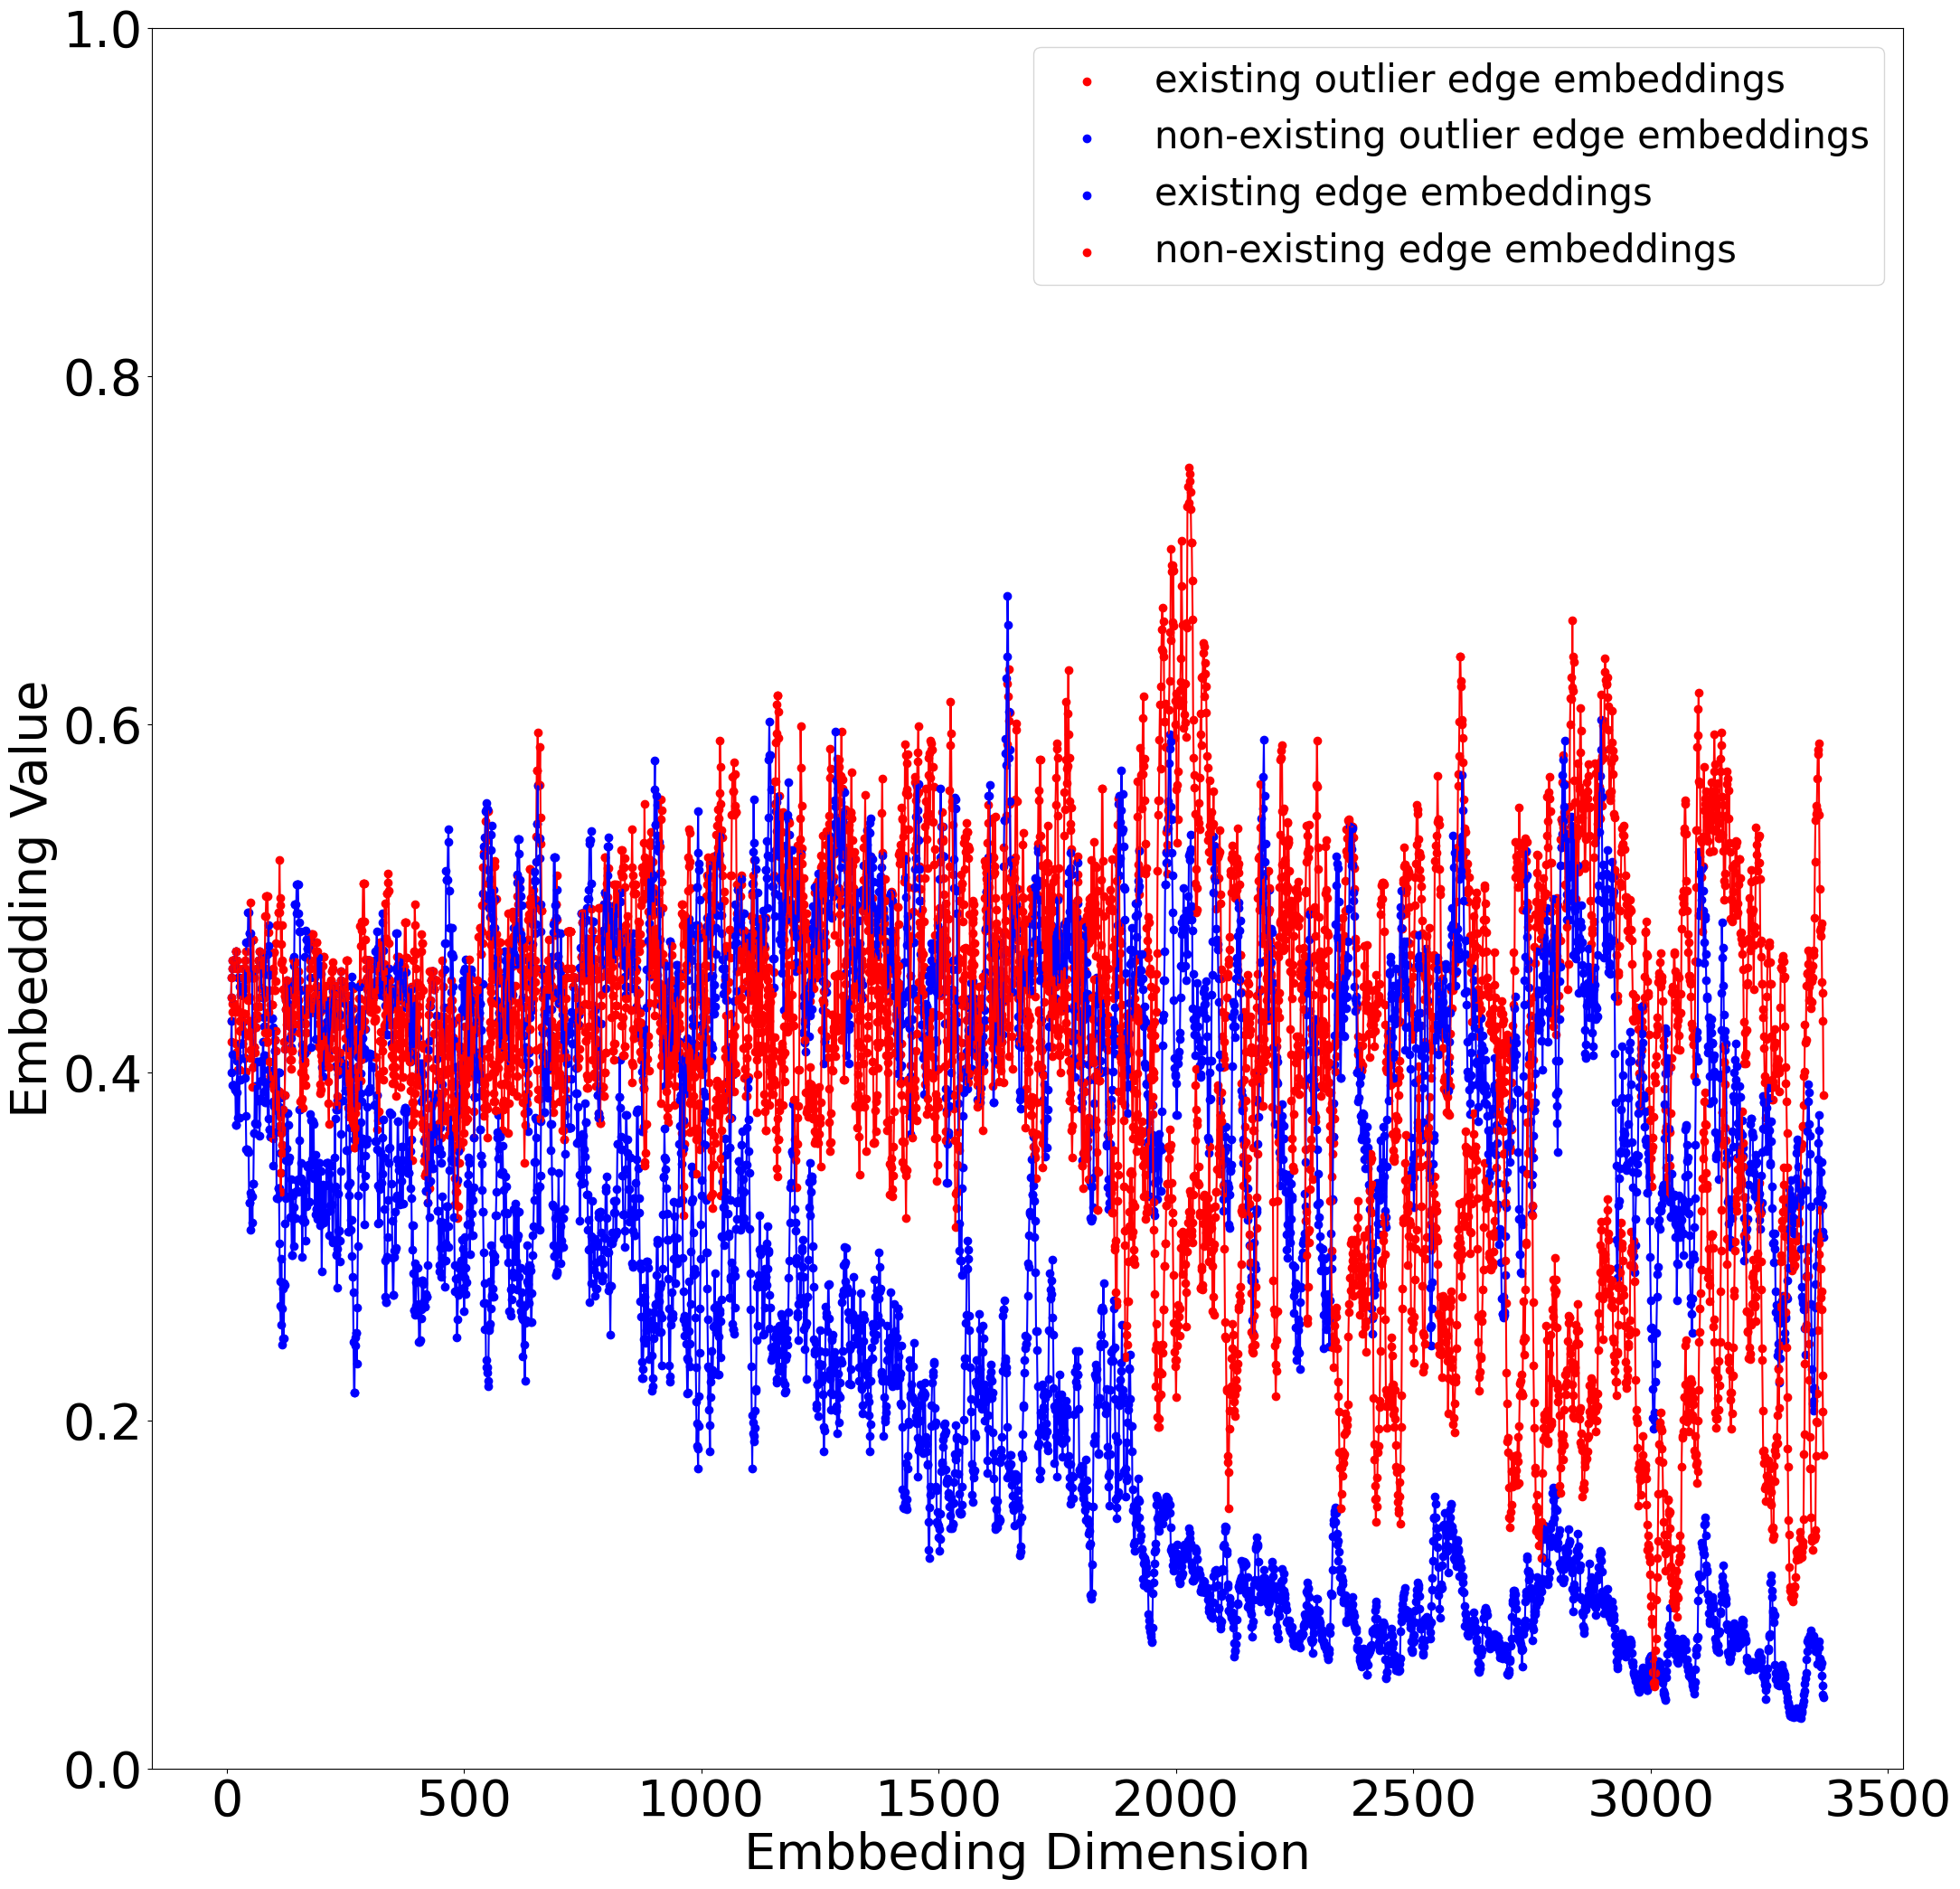

In [8]:
fig = plt.figure(figsize=(25,25))

plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.ylim(0,1)

plt.scatter([i for i in range(len(teste2.iloc[0,:]))],teste2.iloc[0,:].rolling(window=10).mean().values,label="existing outlier edge embeddings",c="red")
plt.plot(teste2.iloc[0,:].rolling(window=10).mean().values,c="red")

plt.scatter([i for i in range(len(teste2.iloc[1,:]))],teste2.iloc[1,:].rolling(window=10).mean().values,label="non-existing outlier edge embeddings",c="blue")
plt.plot(teste2.iloc[1,:].rolling(window=10).mean().values,c="blue")

plt.scatter([i for i in range(len(teste2.iloc[6443,:]))],teste2.iloc[6443,:].rolling(window=10).mean().values,label="existing edge embeddings",c="blue")
plt.plot(teste2.iloc[6443,:].rolling(window=10).mean().values,c="blue")


plt.scatter([i for i in range(len(teste2.iloc[3598,:]))],teste2.iloc[3598,:].rolling(window=10).mean().values,label="non-existing edge embeddings",c="red")
plt.plot(teste2.iloc[3598,:].rolling(window=10).mean().values,c="red")


plt.xlabel("Embbeding Dimension",fontsize=40)
plt.ylabel("Embedding Value",fontsize=40)
plt.legend(fontsize=30) 

# plt.scatter([i for i in range(len(teste2.iloc[2,:]))],teste2.iloc[2,:])
# plt.plot(teste2.iloc[2,:])
# plt.show()
plt.savefig("pca2.png", bbox_inches='tight', pad_inches=0)

/tmp/ipykernel_262621/3179239367.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=30)


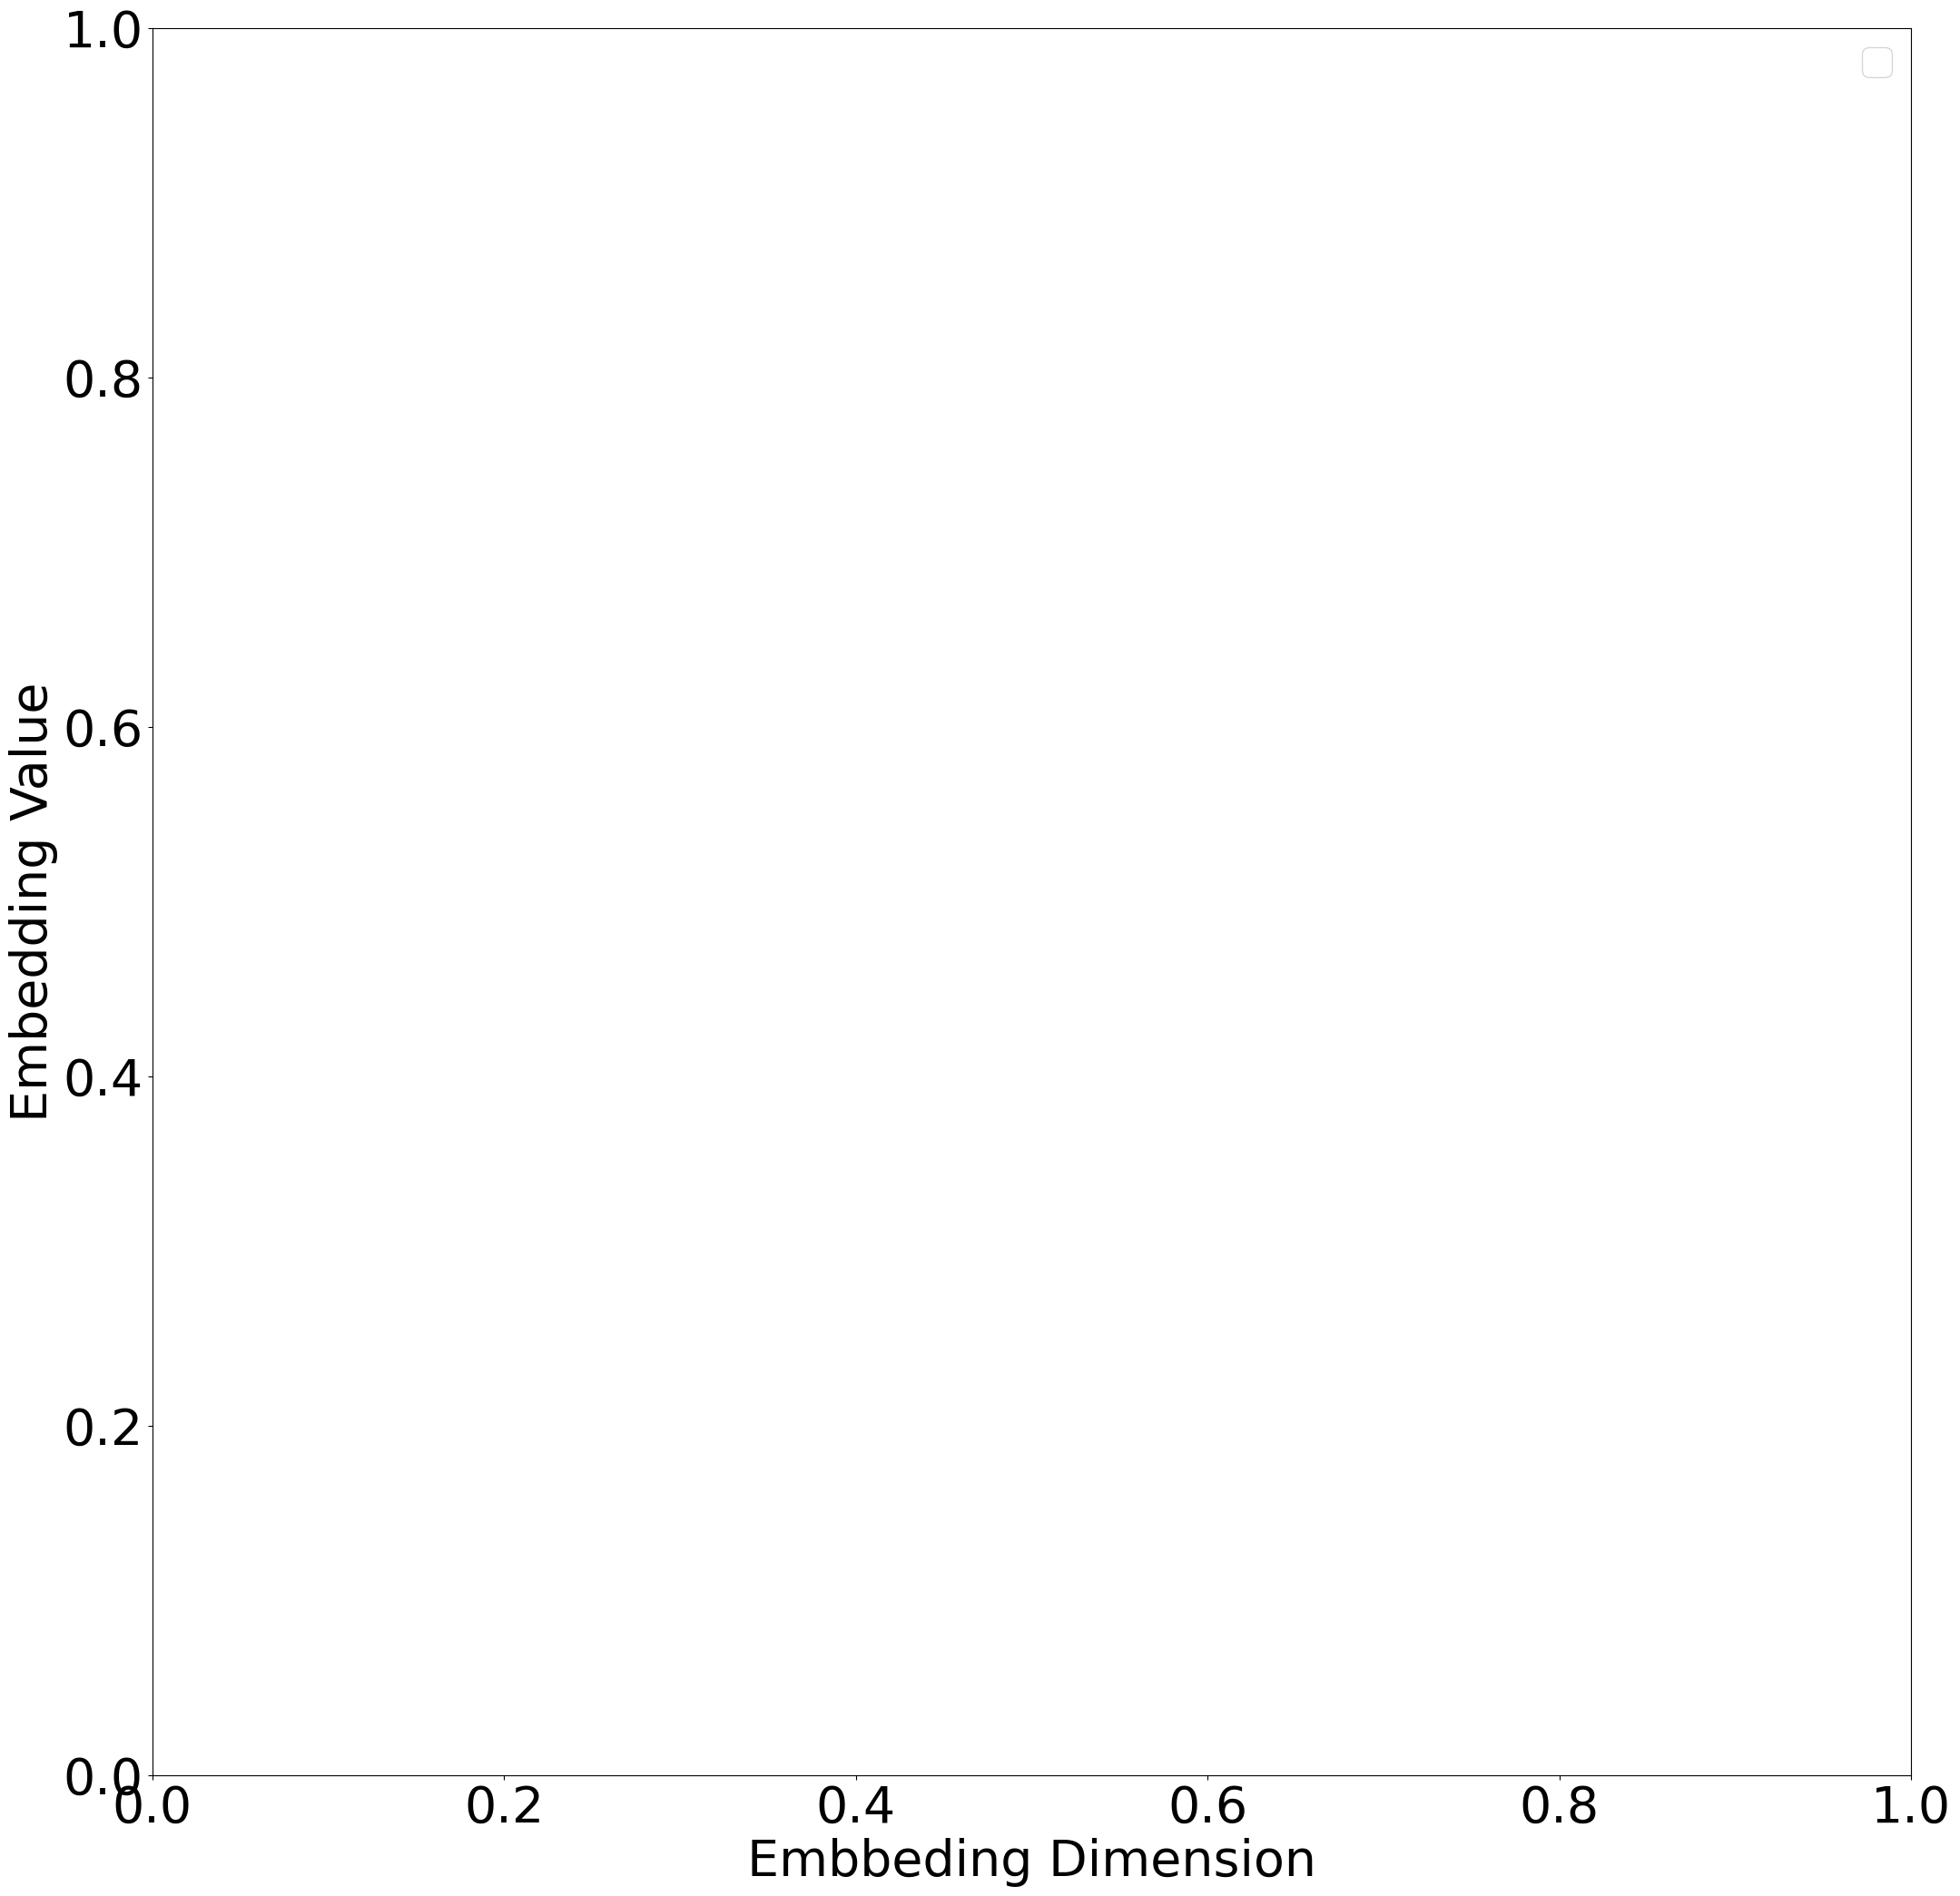

In [9]:
fig = plt.figure(figsize=(25,25))

plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.ylim(0,1)

# plt.scatter([i for i in range(len(df.iloc[0,:].values[2]))],df.iloc[0,:].values[2])
# plt.plot(df.iloc[0,:].values[2])


plt.xlabel("Embbeding Dimension",fontsize=40)
plt.ylabel("Embedding Value",fontsize=40)
plt.legend(fontsize=30) 

# plt.scatter([i for i in range(len(teste2.iloc[2,:]))],teste2.iloc[2,:])
# plt.plot(teste2.iloc[2,:])
# plt.show()
plt.savefig("pca2.png", bbox_inches='tight', pad_inches=0)

/tmp/ipykernel_9973/556233811.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=30)


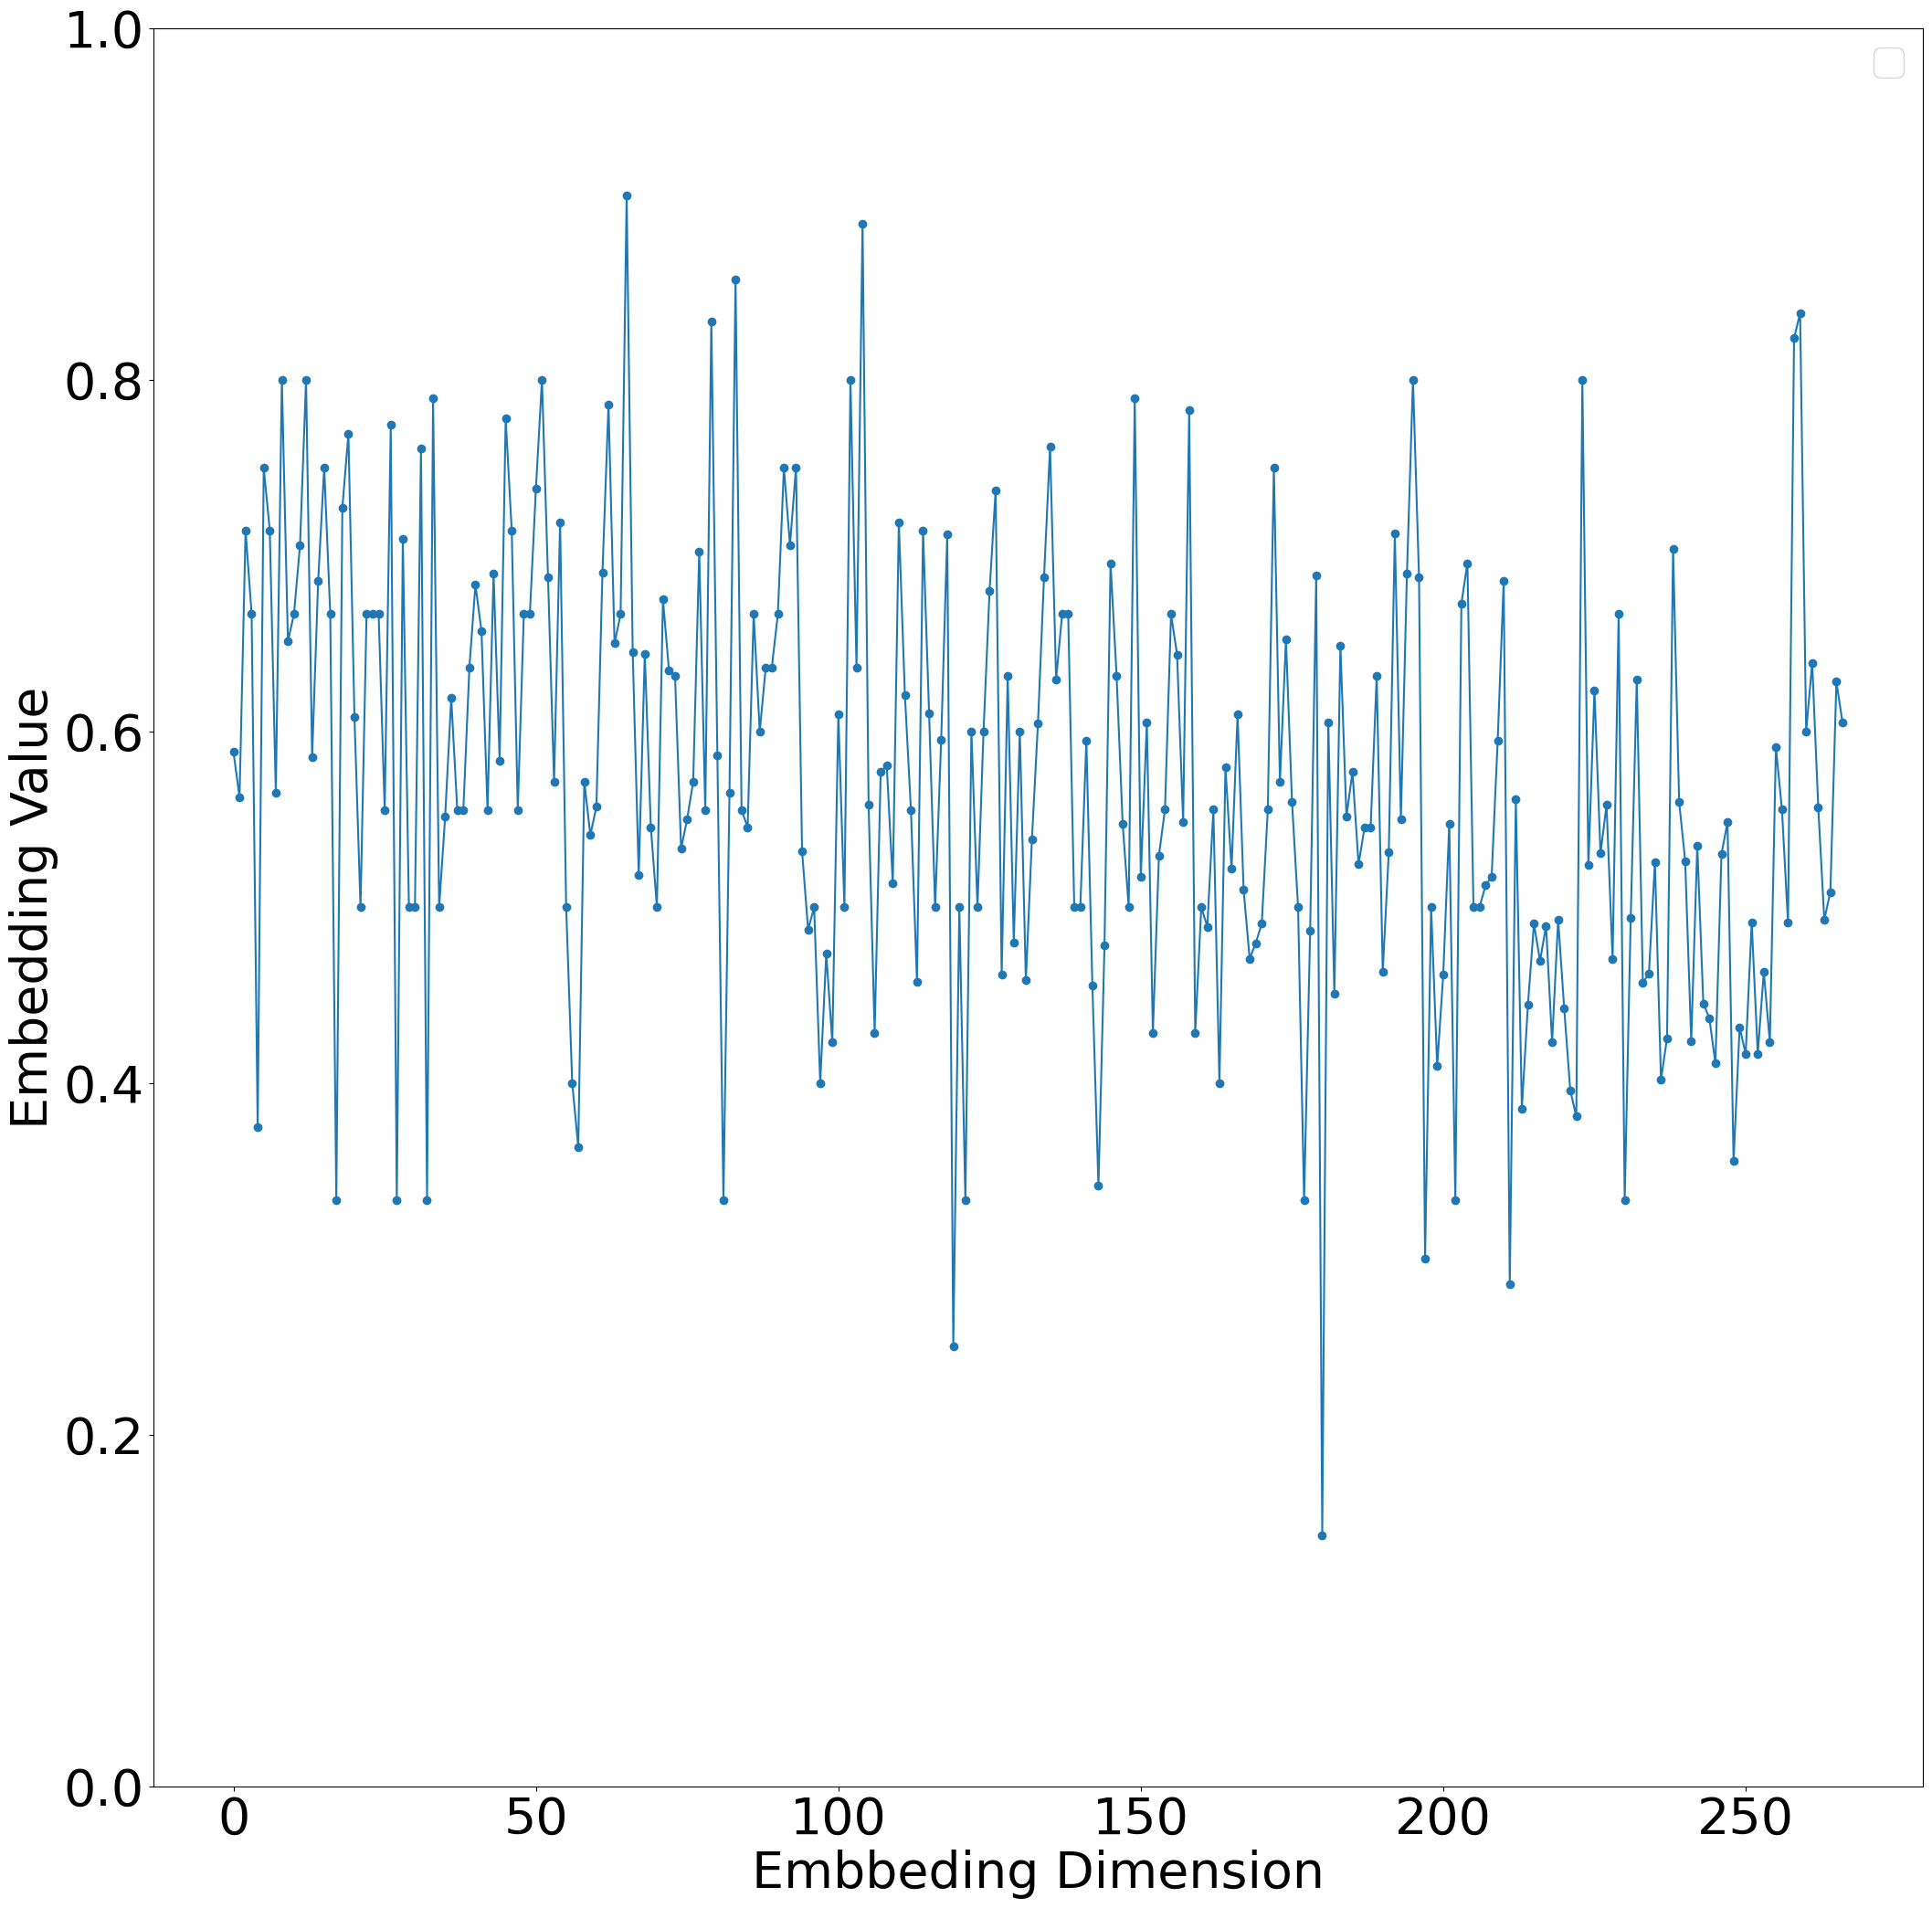

In [204]:
box = pd.Series(teste.iloc[0,:])
box.loc[box.isin([0,1])] = box.mean()


fig = plt.figure(figsize=(25,25))

plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.ylim(0,1)

plt.scatter([i for i in range(len(box))],box)
plt.plot(box)


plt.xlabel("Embbeding Dimension",fontsize=40)
plt.ylabel("Embedding Value",fontsize=40)
plt.legend(fontsize=30) 

# plt.scatter([i for i in range(len(teste2.iloc[2,:]))],teste2.iloc[2,:])
# plt.plot(teste2.iloc[2,:])
# plt.show()

In [ ]:
df2[4].values

(930, 138495)

In [160]:
# df2.iloc[0,:].values
original[0].value_counts()[original[0].value_counts().index.isin(original[original[1]== 930][0].values)].sort_index()

0
138497     12
138506      6
138509     85
138527    129
138532    114
         ... 
144506      8
144550      3
144551     14
144552     16
144648     17
Name: count, Length: 267, dtype: int64

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot()


ax.scatter(red[[0]], red[[1]],c="red")
ax.scatter(blue[[0]], blue[[1]])
ax.scatter(green[[0]],green[[1]],c="green")

ax.set_xlim(-300,300)
ax.set_ylim(-300,300)



plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')


# fig = px.scatter(x=scaled_df[0],y=scaled_df[1], color=scaled_df["label"],
#                  title="Scatter Plot with Iteratively Added Trace")

fig.show()


In [10]:
import pycatch22
# fig = plt.figure(figsize=(50,5))
# plt.scatter([i for i in range(len(teste2.iloc[:,2].values))],teste2.iloc[:,2].rolling(window=100).mean().values)
# plt.scatter([i for i in range(len(teste2.iloc[:,3].values))],teste2.iloc[:,3].rolling(window=100).mean().values)
# plt.scatter([i for i in range(len(teste2.iloc[:,1].values))],teste2.iloc[:,1].rolling(window=100).mean().values)
# plt.scatter([i for i in range(len(teste2.iloc[:,0].values))],teste2.iloc[:,0].rolling(window=100).mean().values)
# plt.show()

# fig = plt.figure(figsize=(50,5))
# plt.scatter([i for i in range(len(teste2.iloc[:,2].values))],teste2.iloc[:,2])
# plt.scatter([i for i in range(len(teste2.iloc[:,3].values))],teste2.iloc[:,3])
# plt.scatter([i for i in range(len(teste2.iloc[:,1].values))],teste2.iloc[:,1])
# plt.scatter([i for i in range(len(teste2.iloc[:,0].values))],teste2.iloc[:,0])
# plt.show()

# x=[i for i in range(teste2.shape[1])]
# x=[teste2.iloc[:,i].fillna(0).values.mean() for i in range(teste2.shape[1])]
teste2 = teste2.T
y=pd.DataFrame([pycatch22.catch22_all((teste2.iloc[:,i].values)) for i in range(teste2.shape[1])])


# fig = px.scatter(x=x,y=y, color=df2_limpo["label"],
#                  title="Scatter Plot with Iteratively Added Trace")



# plt.scatter([i for i in range(teste2.shape[1])],[teste2.iloc[:,i].mean() for i in range(teste2.shape[1])])
# fig.show()


/tmp/ipykernel_262621/1823935647.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


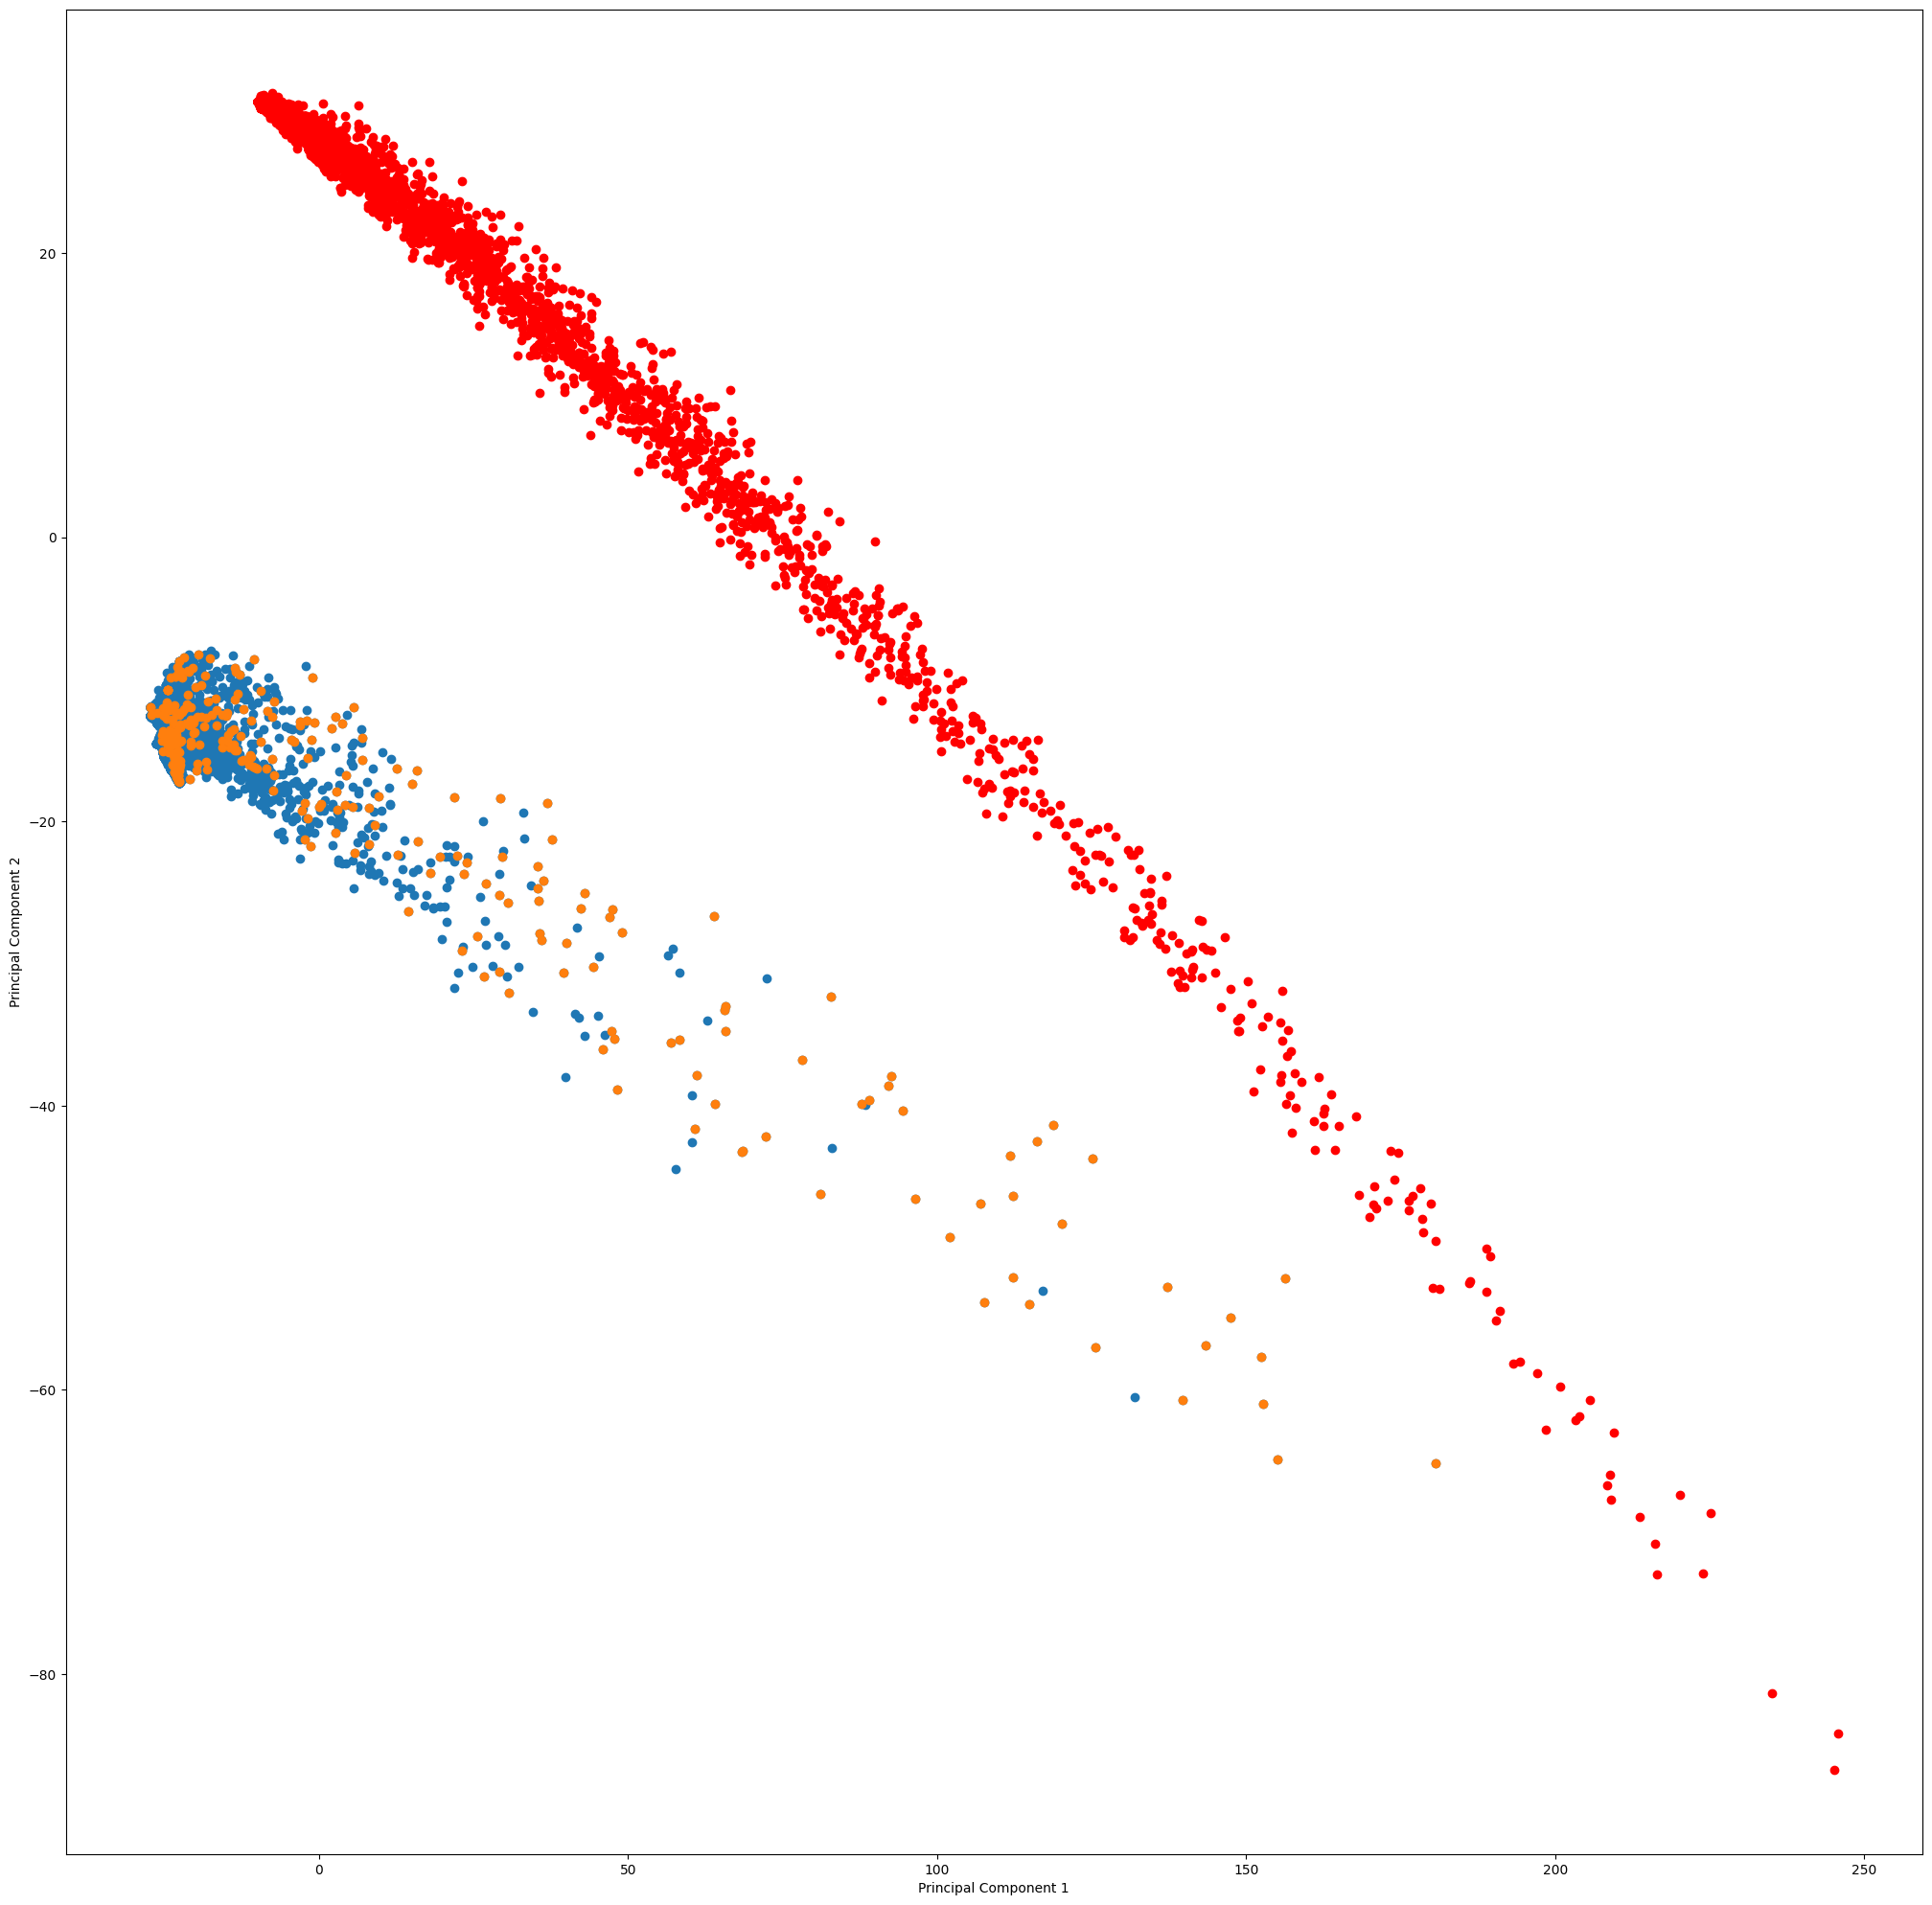

In [11]:
scaler = StandardScaler()
fig = plt.figure(figsize=(25,25))

# tsne = TSNE(n_components=2, random_state=0, perplexity=15)
# X_embedded = tsne.fit_transform(np.array([i for i in y["values"].fillna(0).values]))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)



scaled_df = pd.concat([pd.DataFrame(X_pca),df2[["label","orig"]].reset_index()],axis=1)



red = scaled_df[scaled_df["label"] == 1]
blue = scaled_df[scaled_df["label"] == 0]
green = scaled_df[scaled_df["orig"] == 1]



plt.scatter(red[[0]], red[[1]],c="red")
plt.scatter(blue[[0]], blue[[1]])
plt.scatter(green[[0]],green[[1]])

# plt.xlim(-20,20)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')


# fig = px.scatter(x=scaled_df[0],y=scaled_df[1], color=scaled_df["label"],
#                  title="Scatter Plot with Iteratively Added Trace")

fig.show()


In [ ]:
teste2['rolling_mean'] = teste2.rolling(window=3, center=True).mean()
teste2['rolling_sum'] = teste2.rolling(window=3, center=True).sum()
teste2 = pd.concat([teste2,df2["label"].reset_index()],axis=1)



# fig = plt.figure(figsize=(25,25))

# red = teste2[teste2["label"] == 1]
# blue = teste2[teste2["label"] == 0]
# # plt.xlim(0,10)
# # plt.ylim(0,100)

# plt.scatter(red["0.5"],red["0.1"])
# plt.scatter(blue["0.5"],blue["0.1"])
# plt.loglog(True)
# plt.show()

In [ ]:
teste2.rolling(window=3, center=True).mean()

In [ ]:
def contar_maiores_que_x(df, x, colunas=None):
    """
    Cria uma contagem de valores maiores que 'x' por linha.
    
    df: DataFrame original
    x: Valor de referência para comparação
    colunas: Lista opcional de colunas específicas para analisar
    """
    # Se não especificar colunas, usa todas as colunas numéricas
    if colunas is None:
        df_sub = df.select_dtypes(include=['number'])
    else:
        df_sub = df[colunas]
    
    # Compara cada célula com x e soma os True (1) por linha (axis=1)
    return (df_sub == x).sum(axis=1)

In [ ]:
teste2[f'0.0'] = contar_maiores_que_x(teste2,0)

In [235]:
teste2 = teste2.T

Acurácia: 1.00

Relatório de Classificação:


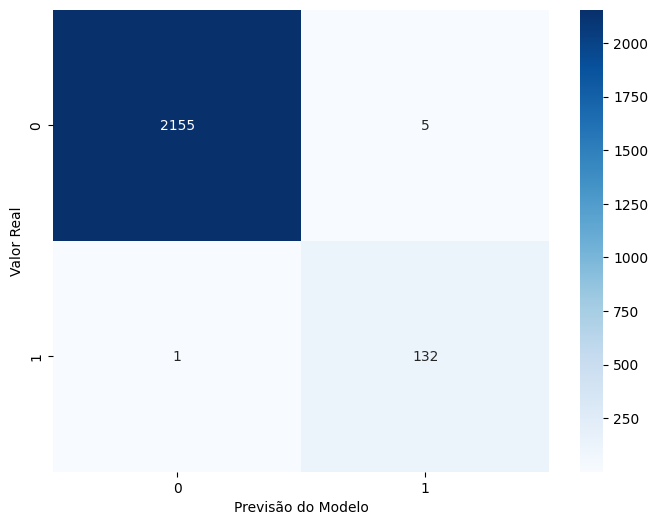

In [236]:
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE


# y = scaled_df["label"]
X_train, X_test, y_train, y_test = train_test_split(teste2,df2["label"], test_size=0.4, random_state=40)
pipeline = Pipeline([
    ('smote', SMOTE()),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=2))
])

pipeline.fit(X_train, y_train)

# 4. Criar e treinar o modelo SVM
# O 'kernel' define como os dados serão projetados no espaço
# modelo = KNeighborsClassifier(n_neighbors=2,weights="distance")
# modelo.fit(X_train, y_train)

# 5. Fazer previsões
previsoes = pipeline.predict(X_test)
# # 6. Avaliar o desempenho
print(f"Acurácia: {accuracy_score(y_test, previsoes):.2f}")
print("\nRelatório de Classificação:")
# print(classification_report(y_test, previsoes))


cm = confusion_matrix(y_test, previsoes)

# 2. Plotar de forma visual (Heatmap)
plt.figure(figsize=(8, 6))  
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
# plt.title('Matriz de Confusão - Classificação de Flores')
plt.show()


In [ ]:
predict = [i[1] for i in previsoes]
predict = pd.DataFrame(predict)
predict_copy = predict.copy()
predict_copy = predict_copy.rename(columns={0:"pred"})
predict_copy["test"] = y_test.values


In [ ]:
predict_copy.pred.value_counts()

In [ ]:
plt.hist(predict_copy[(predict_copy["test"] == 1)].pred)
plt.show()

In [ ]:
df2[df2[4] == 1].index

In [ ]:
predict_copy[y_test.index.isin(df2[df2[4] == 1].index)]

In [ ]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
predict = pd.DataFrame(predict)
xs,ys = [],[]
for threshold in range(0,100):
    predict_copy = predict.copy()
    predict_copy = predict_copy.rename(columns={0:"pred"})
    predict_copy["pred"] = predict_copy["pred"].apply(lambda x : int(x> 0.03*threshold))
    predict_copy["test"] = y_test.values



    xs.append(precision_score(y_true=predict_copy["test"],y_pred=predict_copy["pred"]))
    ys.append(recall_score(y_true=predict_copy["test"],y_pred=predict_copy["pred"]))
    


In [ ]:
y_test

In [ ]:
aux = 0
for i in range(len(xs)-1):
    if(xs[i+1] != 0):
         aux += abs(((ys[i+1]+ys[i])/2)*(xs[i+1]-xs[i]))
print(aux)

In [ ]:
ys

In [ ]:
import matplotlib.pyplot as plt

plt.xlabel("Precision")
plt.ylabel("Recall")
plt.scatter(xs,ys)
plt.show()

In [ ]:
modelo = SVC(kernel='rbf', C=1.0, gamma=0.7)
modelo.fit(X, y)

# 3. Criar uma malha (grid) para cobrir o gráfico
h = .02  # tamanho do passo na malha
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 4. Predizer os valores para cada ponto da malha
Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plotar o resultado
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8) # Áreas de decisão
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired) # Pontos reais
plt.xlabel('Comprimento da Sépala')
plt.ylabel('Largura da Sépala')
plt.title('Fronteiras de Decisão do SVM (Kernel RBF)')
plt.show()

In [ ]:
X

In [ ]:
pca.explained_variance_ratio_